In [1]:
from pathlib import Path
from testing import load_raven_selection_table
import matplotlib.pyplot as plt
import numpy as np

from calibration import (
    load_entries,
    load_template_features_fixed_length,
    frame_hop_len,
    dtw_cross_costs_time,
    compute_pr_curve_from_costs,
    find_threshold_best_f1_from_pr,
    plot_dtw_scatter,
    plot_pr_curve_from_costs,
    save_model_config
)
from feature import(
    make_stft_extractor,
    load_features_from_json,
    make_mfcc_extractor
)

In [2]:
#editable variables
feat_method = "mfcc"
n_calib = 10 #number of calibration templates
n_bg = 100 #number of background templates
n_temps = 10 #number of templates to use for voting
fs_new = 1000
#dtw_method = "old"#**

#feature frame lengths to test
feat_frame_lengths = [0.096, 0.128, 0.192, 0.256, 0.384, 0.512] #[0.048, 0.064, 0.096, 0.128, 0.192, 0.256, 0.384, 0.512]

#window frame lengths to test
window_lengths_to_test = [0.1 ,0.2 ,0.3, 0.4, 0.5, 0.6, 0.7, 0.8] #**

#vote_fractions to test
if n_temps == 5:
    vote_fracs = [0.2, 0.4, 0.6, 0.8, 1.0]
if n_temps == 10:
    vote_fracs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
vote_frac_results = {}

In [3]:
RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")
#Path to get calib_templates
DATA_26 = Path(r"C:\Users\HP\Desktop\Skripsie data\26")
RESULTS_26 = DATA_26 / "template_selections"

#Path to get templates
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

text_path_26 = DATA_26 / "2023-04-26T07-55-05_000_00072.txt"
raven_26 = load_raven_selection_table(text_path_26)

#File names
bg_file = "Bground_CALIB_26_20230426_075505_background.json"

st_calib_file = "ST_CALIB_26_20230426_075505_single_tone_templates.json"
mt_calib_file = "MT_CALIB_26_20230426_075505_multi_tone_templates.json"
bt_calib_file = "BT_CALIB_26_20230426_075505_burst_tonal_templates.json"

st_temp_file = "20230429_Templates_20230429_102841_single_tone_templates.json"
mt_temp_file = "20230429_Templates_20230429_102841_multi_tone_templates.json"
bt_temp_file = "20230429_Templates_20230429_102841_burst_tonal_templates.json"


In [4]:
call_types = ["st", "mt", "bt"]#**

#load start and end times for calibration templates
bg_times = load_entries(RESULTS_26 / bg_file, n_bg)
st_calib_times = load_entries(RESULTS_26 / st_calib_file, n_calib)
mt_calib_times = load_entries(RESULTS_26 / mt_calib_file, n_calib)
bt_calib_times = load_entries(RESULTS_26 / bt_calib_file, n_calib)


=== frame_dur = 0.096s ===
search_len = 1.744s (0.72s + 2*0.512s)
  bt: threshold=14.3553  F1=0.425

=== frame_dur = 0.128s ===
search_len = 1.76s (0.736s + 2*0.512s)
  bt: threshold=13.5061  F1=0.438

=== frame_dur = 0.192s ===
search_len = 1.744s (0.72s + 2*0.512s)
  bt: threshold=12.9959  F1=0.530

=== frame_dur = 0.256s ===
search_len = 1.792s (0.768s + 2*0.512s)
  bt: threshold=12.7958  F1=0.559

=== frame_dur = 0.384s ===
search_len = 1.792s (0.768s + 2*0.512s)
  bt: threshold=12.3385  F1=0.677

=== frame_dur = 0.512s ===
search_len = 1.792s (0.768s + 2*0.512s)
  bt: threshold=12.0151  F1=0.670
Chosen Frame Length: 0.512
Best F1 Score: 0.4579124579124579
st_threshold: 10.598014415549144
mt_threshold: 12.591610471810274
bt_threshold: 12.015060008112854


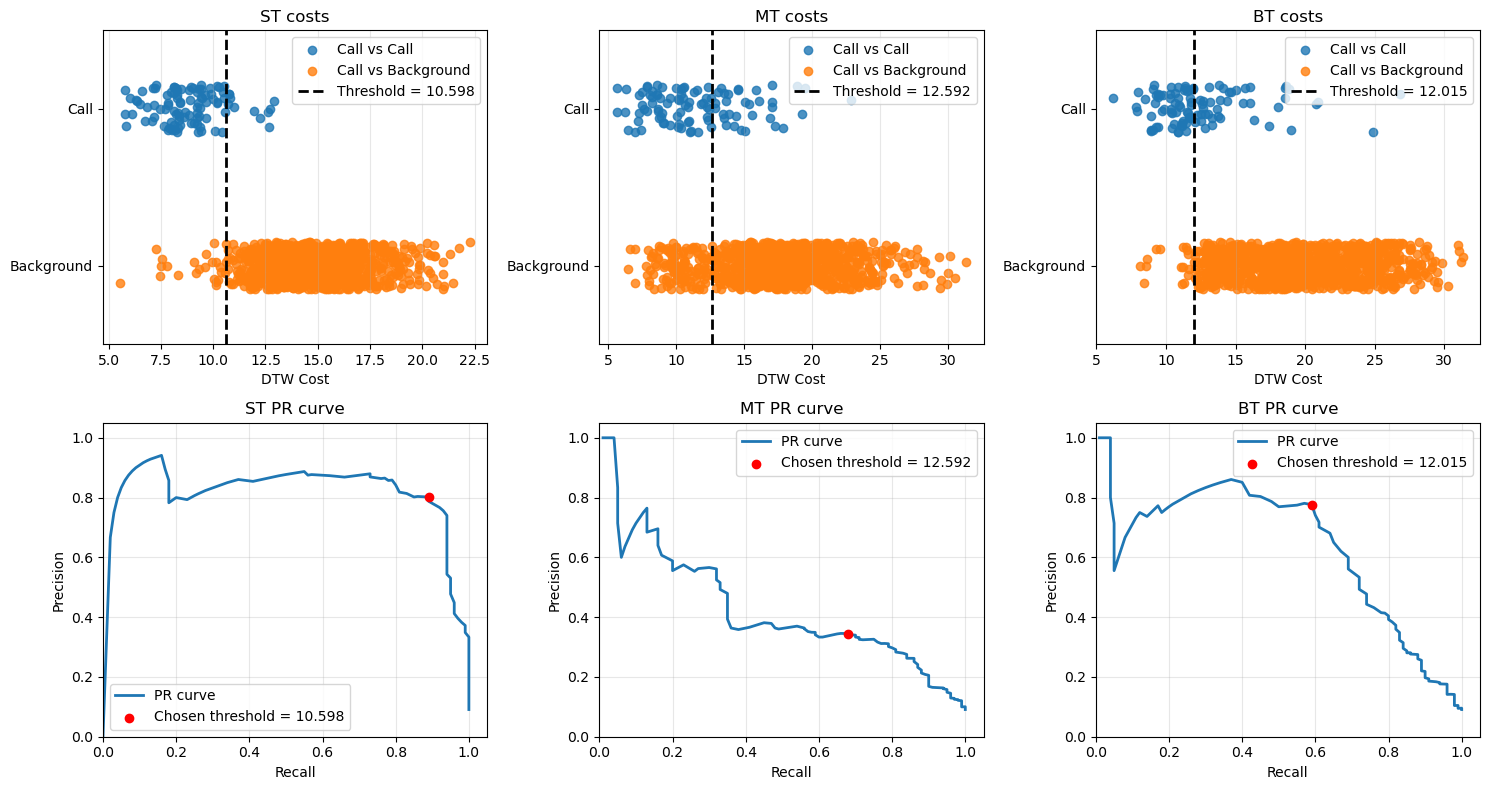

In [5]:
results = {}
search_lens = {}
for frame_length in feat_frame_lengths:
    print(f"\n=== frame_dur = {frame_length}s ===")
    #Type of feature extraction method
    if feat_method == "stft":
        #setup the estractor to be used
        extractor = make_stft_extractor(frame_dur = frame_length)
    elif feat_method == "mfcc":
        extractor = make_mfcc_extractor(frame_dur=frame_length)

    hop_len_seconds = frame_hop_len(extractor, fs_new)

    #determine features
    st_temp_feats = load_features_from_json(RESULTS_29 / st_temp_file, extractor, n_temps)
    mt_temp_feats = load_features_from_json(RESULTS_29 / mt_temp_file, extractor, n_temps)
    bt_temp_feats = load_features_from_json(RESULTS_29 / bt_temp_file, extractor, n_temps)

    #find max template length so all calib feats can be extracted to be same len + slack
    #we want to keep slack small to not let other noise in(checked spectrograms to see if I was happy since there aren't many temps)
    slack_s = 0.512#frame_length   # one STFT frame (frame_dur) on each side
    max_tmpl_s = max(f.shape[1] for fl in (st_temp_feats, mt_temp_feats, bt_temp_feats) for f in fl) * hop_len_seconds 
    search_len = round(max_tmpl_s + 2 * slack_s, 3)
    search_lens[frame_length] = search_len
    print(f"search_len = {search_len}s ({max_tmpl_s}s + 2*{slack_s}s)")

    st_calib_feats =[load_template_features_fixed_length(template, extractor, search_len, fs_new) for template in st_calib_times]
    mt_calib_feats = [load_template_features_fixed_length(template, extractor, search_len, fs_new) for template in mt_calib_times]
    bt_calib_feats = [load_template_features_fixed_length(template, extractor, search_len, fs_new) for template in bt_calib_times]

    bg_feats = [load_template_features_fixed_length(template, extractor, search_len, fs_new) for template in bg_times]

    temp_feats = (st_temp_feats, mt_temp_feats, bt_temp_feats)
    calib_feats = (st_calib_feats, mt_calib_feats, bt_calib_feats)

    results[frame_length] = {}
    for call_type, temps, calibs in zip(call_types, temp_feats, calib_feats):
        call_costs, call_starts, call_ends = dtw_cross_costs_time(temps, calibs, hop_len_seconds, frame_length, extractor.metric)
        bg_costs, bg_starts, bg_ends = dtw_cross_costs_time(temps, bg_feats, hop_len_seconds, frame_length, extractor.metric)

        precision, recall, pr_thresholds = compute_pr_curve_from_costs(call_costs, bg_costs)
        threshold, f1 = find_threshold_best_f1_from_pr(precision, recall, pr_thresholds)

        results[frame_length][call_type] = dict(
            threshold=threshold, f1=f1,
            call_costs=call_costs, call_starts=call_starts, call_ends=call_ends,
            bg_costs=bg_costs, bg_starts=bg_starts, bg_ends=bg_ends,
        )
    print(f"  {call_type}: threshold={threshold:.4f}  F1={f1:.3f}")

frame_len_results = {f: min(r["f1"] for r in results[f].values()) for f in results}
best_frame_len = max(frame_len_results, key=lambda f: (frame_len_results[f], f))
best_score = frame_len_results[best_frame_len]
best_thresholds = {t: results[best_frame_len][t]["threshold"] for t in call_types}

print(f"Chosen Frame Length: {best_frame_len}")
print(f"Best F1 Score: {best_score}")
for t in call_types:
    print(f"{t}_threshold: {best_thresholds[t]}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, t in enumerate(call_types):
    r = results[best_frame_len][t]
    plot_dtw_scatter(r["call_costs"], r["bg_costs"], threshold=r["threshold"], ax=axes[0, col])
    plot_pr_curve_from_costs(r["call_costs"], r["bg_costs"], best_threshold=r["threshold"], ax=axes[1, col])
    axes[0, col].set_title(f"{t.upper()} costs")
    axes[1, col].set_title(f"{t.upper()} PR curve")
plt.tight_layout()
plt.show()

In [6]:
if feat_method == "stft":
    extractor = make_stft_extractor(frame_dur = best_frame_len)
elif feat_method == "mfcc":
    extractor = make_mfcc_extractor(frame_dur=best_frame_len)
    
hop_len_seconds = frame_hop_len(extractor, fs_new)
best_search_len = search_lens[best_frame_len]

bg_feats = [load_template_features_fixed_length(template_number, extractor, best_search_len, fs_new = fs_new) for template_number in bg_times]

st_calib_feats = [load_template_features_fixed_length(template_number, extractor, best_search_len, fs_new = fs_new) for template_number in st_calib_times]
mt_calib_feats = [load_template_features_fixed_length(template_number, extractor, best_search_len, fs_new = fs_new) for template_number in mt_calib_times]
bt_calib_feats = [load_template_features_fixed_length(template_number, extractor, best_search_len, fs_new = fs_new) for template_number in bt_calib_times]

st_temp_feats = load_features_from_json(RESULTS_29 / st_temp_file, extractor, n_temps)
mt_temp_feats = load_features_from_json(RESULTS_29 / mt_temp_file, extractor, n_temps)
bt_temp_feats = load_features_from_json(RESULTS_29 / bt_temp_file, extractor, n_temps)

calib_feats = {
    "st": st_calib_feats,
    "mt": mt_calib_feats,
    "bt": bt_calib_feats,
    "bg": bg_feats
}

temp_feats = {
    "st": st_temp_feats,
    "mt": mt_temp_feats,
    "bt": bt_temp_feats
}

call_thresholds = best_thresholds

# DTW once per (clip set, template type): it does not depend on vote_frac
cost_mats = {}
for set_name, clips in calib_feats.items():
    for temp_name, temps in temp_feats.items():
        flat, _, _ = dtw_cross_costs_time(temps, clips, hop_len_seconds, best_frame_len, extractor.metric)
        cost_mats[(set_name, temp_name)] = np.asarray(flat).reshape(len(temps), len(clips))

triggered = {}

for vote_frac in vote_fracs:

    for (set_call_type, temp_call_type), mat in cost_mats.items():

        for thr_call_type, call_threshold in call_thresholds.items():
                call_votes = (mat <= call_threshold).sum(axis=0)#true if cost smaller than threshold
                call_triggered = call_votes >= np.ceil(vote_frac * n_temps) #true if more than vote frac agree
                triggered[(vote_frac, set_call_type, temp_call_type, thr_call_type)] = call_triggered 

call_sets = ["st", "mt", "bt"]

f1_scores = {}   # (vote_frac, temp_type, thr_type) -> f1
for vote_frac in vote_fracs:
    for temp_type in temp_feats:
        for thr_type in call_thresholds:
            pos_trig = np.concatenate([triggered[(vote_frac, call_label, temp_type, thr_type)] for call_label in call_sets])          # every call example
            neg_trig = triggered[(vote_frac, "bg", temp_type, thr_type)]  # background only

            tp = pos_trig.sum()
            fn = (~pos_trig).sum()
            fp = neg_trig.sum()

            p = tp / (tp + fp) if (tp + fp) else 0.0
            r = tp / (tp + fn) if (tp + fn) else 0.0
            f1 = 2 * p * r / (p + r) if (p + r) else 0.0
            f1_scores[(vote_frac, temp_type, thr_type)] = f1
            #print(f"vote_frac={vote_frac:.1f} temps={temp_type} thr={thr_type}: P={p:.2f} R={r:.2f} F1={f1:.2f}")

# choose vote_frac: best worst-case F1 across all template/threshold combinations
best_vote_frac = max(vote_fracs, key=lambda v: (min(f1_scores[(v, t, th)] for t in temp_feats for th in call_thresholds), v))
print("Best vote_frac:", best_vote_frac)

Best vote_frac: 0.2


In [7]:
MODEL_CONFIG = RESULTS / f"model_config_{feat_method}_{n_temps}.json"

save_model_config(
    MODEL_CONFIG,
    feat_method=feat_method,
    extractor=extractor,
    fs_new=fs_new,
    best_frame_len=best_frame_len,
    search_len_s=best_search_len,
    thresholds=call_thresholds,          # {"st": st_threshold, ...}
    best_vote_frac=best_vote_frac,
    n_temps=n_temps,
    n_calib=n_calib,
    best_f1=best_score,
    vote_f1_scores=f1_scores,
    template_files={"st": st_temp_file, "mt": mt_temp_file, "bt": bt_temp_file},
);

Saved model config to C:\Users\HP\Desktop\Skripsie data\Results\model_config_mfcc_10.json
